In [1]:
import pandas as pd 
import numpy as np
import  matplotlib.pyplot as plt 


In [2]:
file_path=(r"C:\Users\Hp\Documents\NareshIT\Data_Files\Visadataset.csv")
visa_df=pd.read_csv(file_path)
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [5]:
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [7]:
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [9]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [11]:
visa_df['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [13]:
visa_df['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

- There are total 25480 applicants are there
- in that 25480 applicants 17018 applicants got the visa
- 8462 applicants did not get the visa
- also there are 16851 applucants are applied for visa from asia
- we want to know how many applicants from asia got certified
- and how many applicants from asia got denied 

In [20]:
# step 1 : select the continent data
# step 2 : continent asia == 'Asia' it is con1
# step 3 : select the case status data
# step 4 : case status data == 'Certified' is con2
# step 5 : con=con1& con2
# step 6 : apply main df on con get the len 

In [15]:
con1=visa_df['continent']=='Asia'
con2=visa_df['case_status']=='Certified'
con=con1&con2
len(visa_df[con])

11012

In [13]:
# from diff continents how many people are certified 


In [17]:
for i in visa_df['continent'].unique():
    con1=visa_df['continent']==i
    con2=visa_df['case_status']=='Certified'
    con=con1&con2
    print(i,':',len(visa_df[con]))
        

Asia : 11012
Africa : 397
North America : 2037
Europe : 2957
South America : 493
Oceania : 122


In [19]:
certified=[]
not_certified=[]
labels=visa_df['continent'].unique()
for i in labels:
    con1=con1=visa_df['continent']==i
    con2=visa_df['case_status']=='Certified'
    con3=visa_df['case_status']=='Denied'
    cert_con=con1&con2
    not_cert=con1&con3
    # certified.append(cert_con)
    # not_certified.append(not_cert)
    certified.append(len(visa_df[cert_con]))
    not_certified.append(len(visa_df[not_cert]))
cols=sorted(visa_df['case_status'].unique())

In [21]:
pd.DataFrame(zip(certified,not_certified),columns=cols,index=labels)

,Certified,Denied
Asia,11012,5849
Africa,397,154
North America,2037,1255
Europe,2957,775
South America,493,359
Oceania,122,70


# CROSS TAB

In [23]:
col1=visa_df['continent']
col2=visa_df['case_status']
r1=pd.crosstab(col1,col2)
r1

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


<Axes: xlabel='continent'>

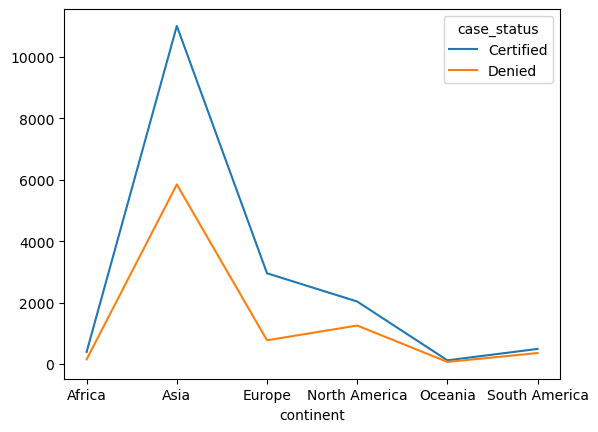

In [25]:
r1.plot()

<Axes: xlabel='continent'>

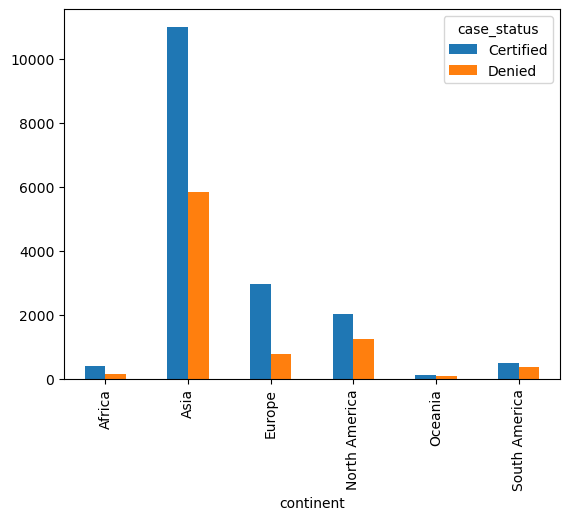

In [27]:
r1.plot(kind='bar')

**case status - continent - education_of_employee**

- from Asia there are 16k applicants applied for visa
  - in that 11k ppl got certuified
      - in that 11k ppl diff education applicants are available 


In [30]:
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col1,col2]
r2=pd.crosstab(cols,col3)

<Axes: ylabel='Frequency'>

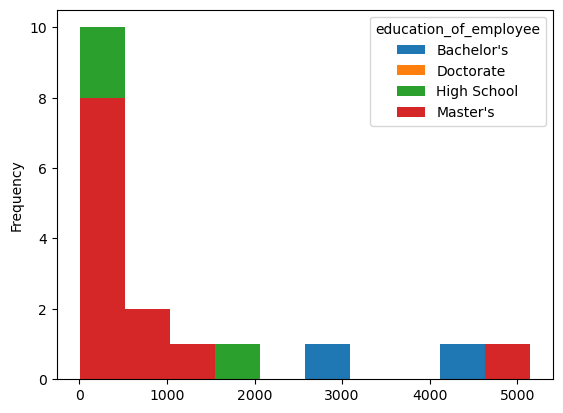

In [32]:
r2.plot(kind='hist')

<Axes: xlabel='continent,case_status'>

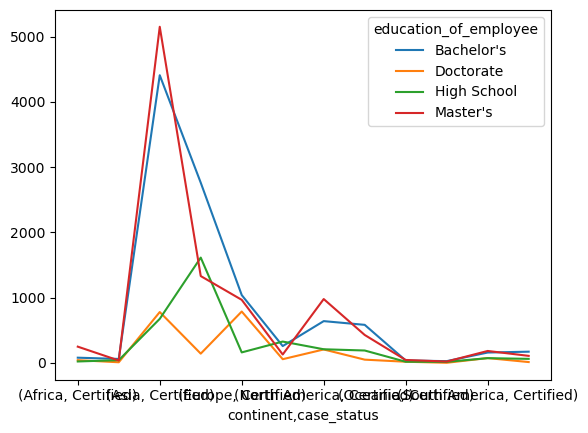

In [34]:
r2.plot()

# GROUP BY 

In [37]:
visa_df['education_of_employee'].value_counts()

education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64

In [39]:
visa_df['prevailing_wage']

0           592.2029
1         83425.6500
2        122996.8600
3         83434.0300
4        149907.3900
            ...     
25475     77092.5700
25476    279174.7900
25477    146298.8500
25478     86154.7700
25479     70876.9100
Name: prevailing_wage, Length: 25480, dtype: float64

In [41]:
list(visa_df.groupby('education_of_employee'))

[("Bachelor's",
           case_id      continent education_of_employee has_job_experience  \
  2         EZYV03           Asia            Bachelor's                  N   
  3         EZYV04           Asia            Bachelor's                  N   
  6         EZYV07           Asia            Bachelor's                  N   
  7         EZYV08  North America            Bachelor's                  Y   
  8         EZYV09           Asia            Bachelor's                  N   
  ...          ...            ...                   ...                ...   
  25466  EZYV25467         Europe            Bachelor's                  Y   
  25468  EZYV25469           Asia            Bachelor's                  N   
  25473  EZYV25474           Asia            Bachelor's                  Y   
  25475  EZYV25476           Asia            Bachelor's                  Y   
  25479  EZYV25480           Asia            Bachelor's                  Y   
  
        requires_job_training  no_of_employee

In [43]:
visa_df.groupby('education_of_employee').count()

,case_id,continent,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
education_of_employee,,,,,,,,,,,
Bachelor's,10234,10234,10234,10234,10234,10234,10234,10234,10234,10234,10234
Doctorate,2192,2192,2192,2192,2192,2192,2192,2192,2192,2192,2192
High School,3420,3420,3420,3420,3420,3420,3420,3420,3420,3420,3420
Master's,9634,9634,9634,9634,9634,9634,9634,9634,9634,9634,9634


In [45]:
visa_df.groupby('education_of_employee').size()

education_of_employee
Bachelor's     10234
Doctorate       2192
High School     3420
Master's        9634
dtype: int64

In [47]:
visa_df.groupby('education_of_employee')['prevailing_wage']

In [49]:
visa_df['prevailing_wage'].mean()

74455.81459209183

In [51]:
visa_df.groupby('education_of_employee')['prevailing_wage'].mean()

education_of_employee
Bachelor's     73405.443735
Doctorate      64561.076657
High School    71582.147756
Master's       78843.057843
Name: prevailing_wage, dtype: float64

In [53]:
con=visa_df['case_status']=='Denied'
new_df=visa_df[con]
new_df.groupby('continent').size()

continent
Africa            154
Asia             5849
Europe            775
North America    1255
Oceania            70
South America     359
dtype: int64

In [55]:
con=visa_df['case_status']=='Certified'
new_df=visa_df[con]
new_df.groupby('continent').size()

continent
Africa             397
Asia             11012
Europe            2957
North America     2037
Oceania            122
South America      493
dtype: int64

In [57]:
visa_df['prevailing_wage'].min()
con=visa_df['continent']=='Asia'
new_df=visa_df[con]
new_df['prevailing_wage'].min()

3.3188

In [59]:
visa_df.groupby('continent')['prevailing_wage'].min()

continent
Africa           32.9286
Asia              3.3188
Europe            9.1753
North America     2.1367
Oceania          24.4888
South America     3.0031
Name: prevailing_wage, dtype: float64

- we need to perform two numberical column analysis
    - This will give relation between two columns which are numerical in nature
    - so we can perform correlation matrix to get the relationship
    - also we need to perfrom scatter plots to visualize the relation 

**PLT.SCATTER**

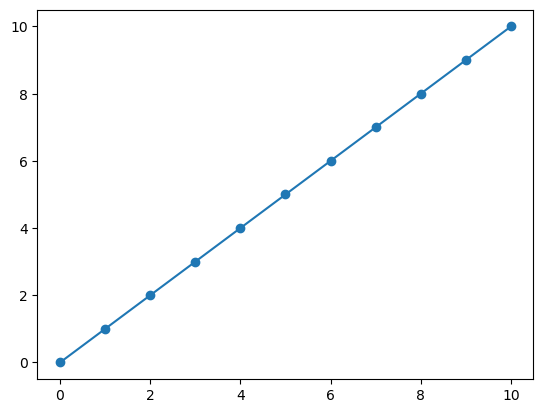

In [72]:
x=range(0,11)
y=range(0,11)
plt.scatter(x,y)
plt.plot(x,y)

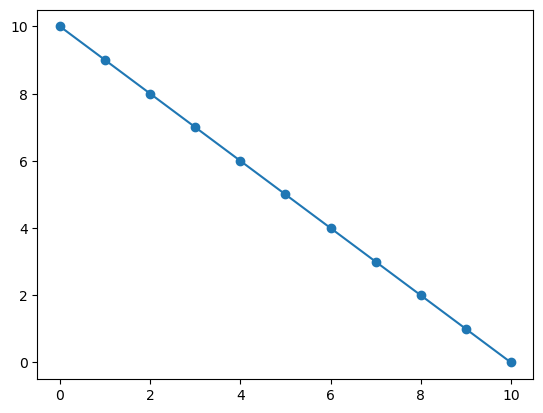

In [78]:
x=range(0,11)
y=range(10,-1,-1)
plt.scatter(x,y)
plt.plot(x,y)

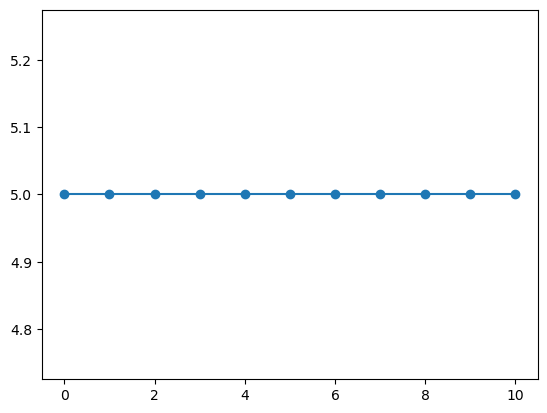

In [84]:
x=range(0,11)
y=[5 for i in range(0,11)]
plt.scatter(x,y)
plt.plot(x,y)

In [170]:
visa_corr=visa_df.corr(numeric_only=True)

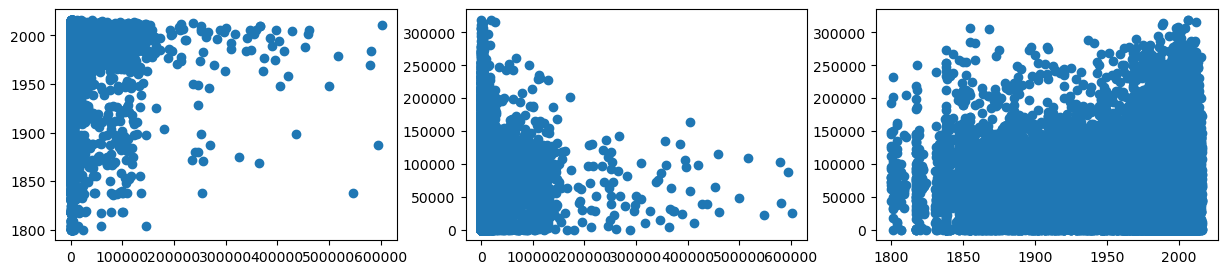

In [114]:
a=visa_df['no_of_employees']
b=visa_df['yr_of_estab']
c=visa_df['prevailing_wage']
plt.figure(figsize=(15,3))
plt.subplot(1,3,1).scatter(a,b)
plt.subplot(1,3,2).scatter(a,c)
plt.subplot(1,3,3).scatter(b,c)

In [128]:
file_path=r"C:\Users\Hp\Documents\NareshIT\Data_Files\winequality_red.csv"

In [132]:
vine_df=pd.read_csv(file_path)

In [148]:
num=vine_df.select_dtypes(exclude='O').columns
col=vine_df.select_dtypes(include='O').columns
col

Index([], dtype='object')

In [150]:
num

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [157]:
a=vine_df['fixed acidity']
b=vine_df['volatile acidity']
c=vine_df['citric acid']
d=vine_df['residual sugar']
e=vine_df['chlorides']

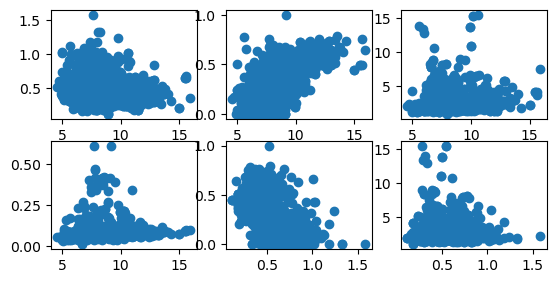

In [159]:
plt.subplot(3,3,1).scatter(a,b)
plt.subplot(3,3,2).scatter(a,c)
plt.subplot(3,3,3).scatter(a,d)
plt.subplot(3,3,4).scatter(a,e)
plt.subplot(3,3,5).scatter(b,c)
plt.subplot(3,3,6).scatter(b,d)


In [166]:
vine_corr=vine_df.corr()

# Heat map

- ANY MATRIX VALUE WE CAN VISUALIZE USING A HEAT MAP
- HEAP MAP WILL PROVIDE COLORS FOR DIFFERENT VALUES
- HEAP MAP ALSO PROVIDES COLORS BAR WHICH INDCATES ,THE COLOR AND ITS VALUE
- FOR EXAMPLE THE VALUES RANGE FROM 0.8 TO 1 DISPLAY AS BLUE COLOR
- SO WE NEED TO CHECK VALUES, WE CAN DIRECTLY SEE THE BLUE COLOR
- SO IMMEDIATELY WE CAN SENCE BLUE COLOR MEANS HIGHEST VALUE WHICH IS BETWEEN 0.8 TO 1
- HEAT MAP AVAILABLE IN SEABORN 

In [164]:
import seaborn as sns 

<Axes: >

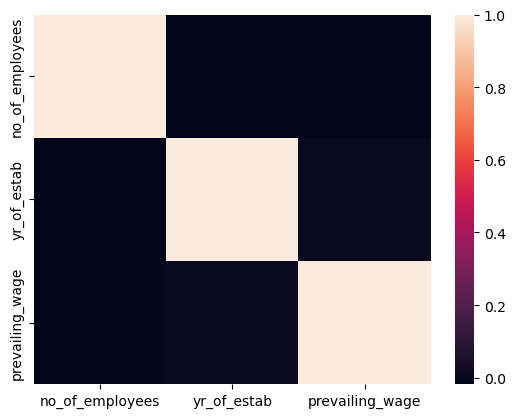

In [172]:
sns.heatmap(visa_corr)

<Axes: >

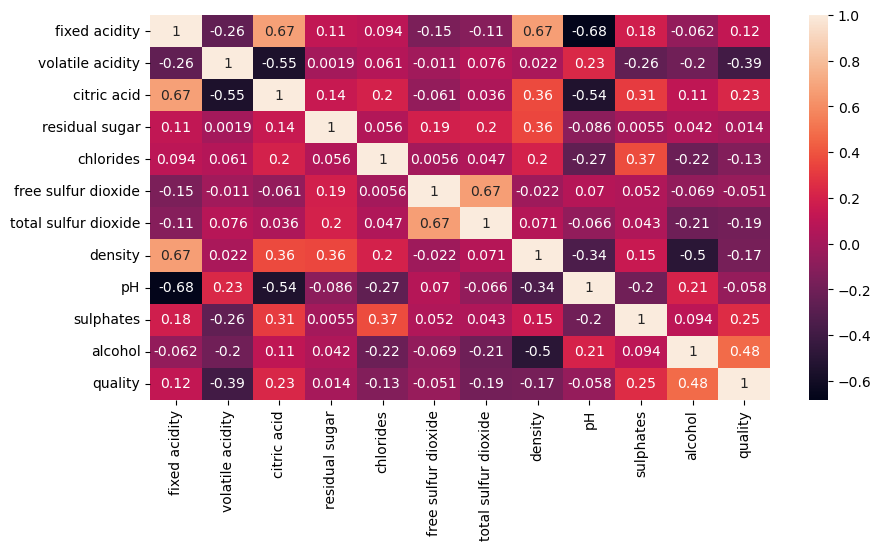

In [178]:
plt.figure(figsize=(10,5))
sns.heatmap(vine_corr,annot=True)